# Data Analysis

This notebook visualizes the cleaned suicide rate data to find patterns and trends before building models.

We look at correlations, time trends, regional differences, and whether the relationship between economics and suicide differs by income level.

In [1]:
%pip install matplotlib
%pip install seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set consistent plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Load cleaned datasets from the data preparation step
df_agestd = pd.read_csv('age_std_suicide_rates_cleaned.csv')
df_granular = pd.read_csv('suicide_rates_cleaned.csv')

print(f'Age-standardized: {df_agestd.shape[0]:,} rows × {df_agestd.shape[1]} columns')
print(f'Granular: {df_granular.shape[0]:,} rows × {df_granular.shape[1]} columns')

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------------------------------------ --- 7.3/8.1 MB 42.4 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 34.5 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 38.6 MB/s  0:00:00

   ---------------------------------------- 0/6 [pyparsing]
   ------ --------------------------------- 1/6 [kiwisolver]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- 


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\SebastianStanik\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\SebastianStanik\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Age-standardized: 5,832 rows × 33 columns
Granular: 94,989 rows × 30 columns


---
## 1. Correlation Heatmap

Visualizes the strength and direction of linear relationships between the age-standardized death rate and all economic indicators. This provides an initial overview of which variables may be significant predictors before formal regression modeling.

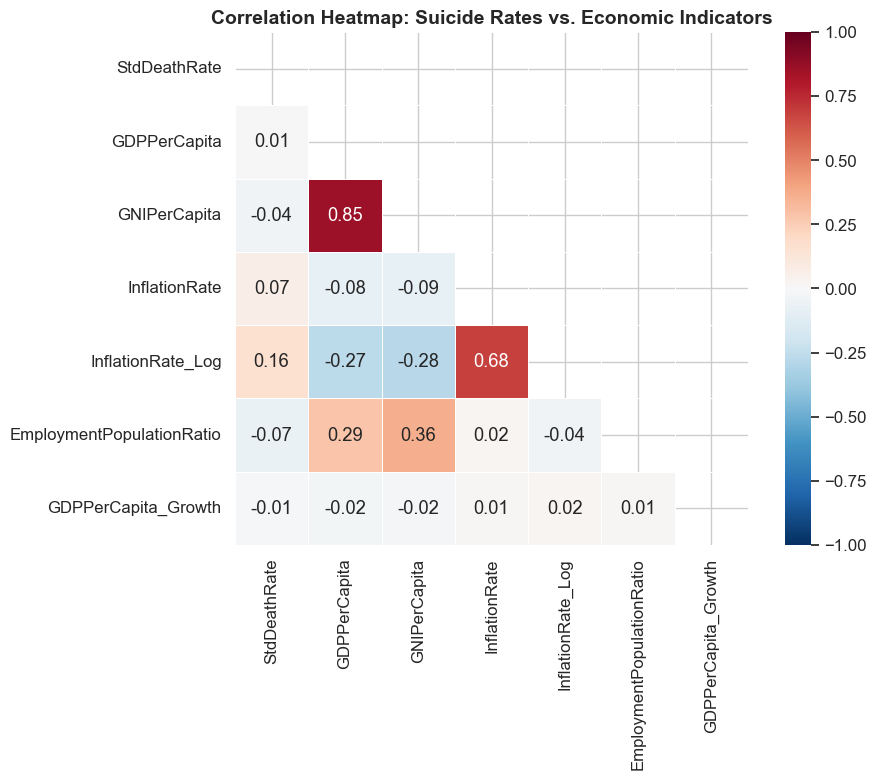

In [2]:
# Build a correlation matrix between suicide rate and economic indicators
corr_cols = ['StdDeathRate', 'GDPPerCapita', 'GNIPerCapita',
             'InflationRate', 'InflationRate_Log',
             'EmploymentPopulationRatio', 'GDPPerCapita_Growth']

corr_cols = [c for c in corr_cols if c in df_agestd.columns]

corr_matrix = df_agestd[corr_cols].corr()

# Plot heatmap with a mask to only show the lower triangle
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap: Suicide Rates vs. Economic Indicators', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', bbox_inches='tight')
plt.show()

---
## 2. Time-Series Trends: Global Suicide Rates (1990-2022)

Plots the average global StdDeathRate over time, split by sex (Male vs. Female). Vertical shaded regions mark the **2008 Financial Crisis** (2008-2010) and **COVID-19** (2020-2021) to visually assess whether suicide rate spikes align with known economic downturns.

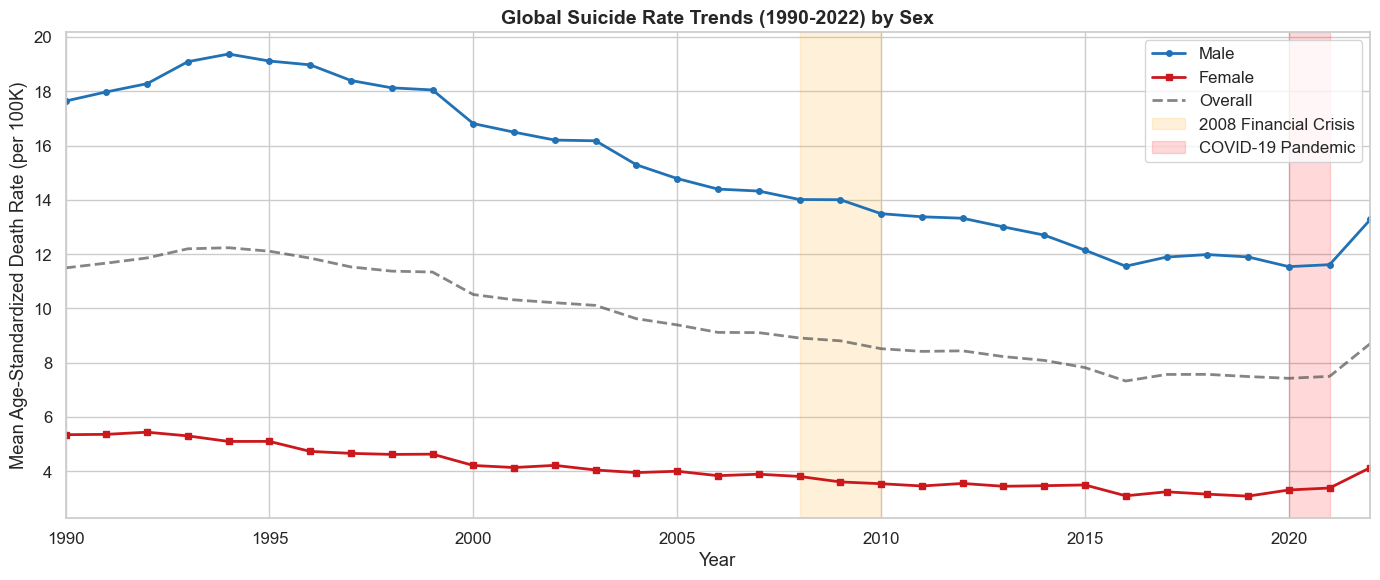

In [3]:
# Plot global suicide rate trends over time, split by sex
# Shaded regions mark the 2008 crisis and COVID-19 pandemic
ts_data = df_agestd.groupby(['Year', 'Sex'])['StdDeathRate'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))

for sex, color, marker in [('Male', '#2171b5', 'o'), ('Female', '#cb181d', 's')]:
    subset = ts_data[ts_data['Sex'] == sex]
    ax.plot(subset['Year'], subset['StdDeathRate'], color=color, marker=marker,
            markersize=4, linewidth=2, label=sex)

# Overall trend line
ts_overall = df_agestd.groupby('Year')['StdDeathRate'].mean()
ax.plot(ts_overall.index, ts_overall.values, color='#525252', linewidth=2,
        linestyle='--', label='Overall', alpha=0.7)

# Highlight economic crisis periods
ax.axvspan(2008, 2010, alpha=0.15, color='orange', label='2008 Financial Crisis')
ax.axvspan(2020, 2021, alpha=0.15, color='red', label='COVID-19 Pandemic')

ax.set_xlabel('Year')
ax.set_ylabel('Mean Age-Standardized Death Rate (per 100K)')
ax.set_title('Global Suicide Rate Trends (1990-2022) by Sex', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.set_xlim(1990, 2022)
plt.tight_layout()
plt.savefig('fig_timeseries_trends.png', bbox_inches='tight')
plt.show()

---
## 3. Regional Comparison: Average StdDeathRate by WHO Region and Sex

Compares average suicide rates across the 6 WHO regions, highlighting geographic disparities. The male/female split reveals the demographic vulnerability pattern identified by Meda et al. (2022).

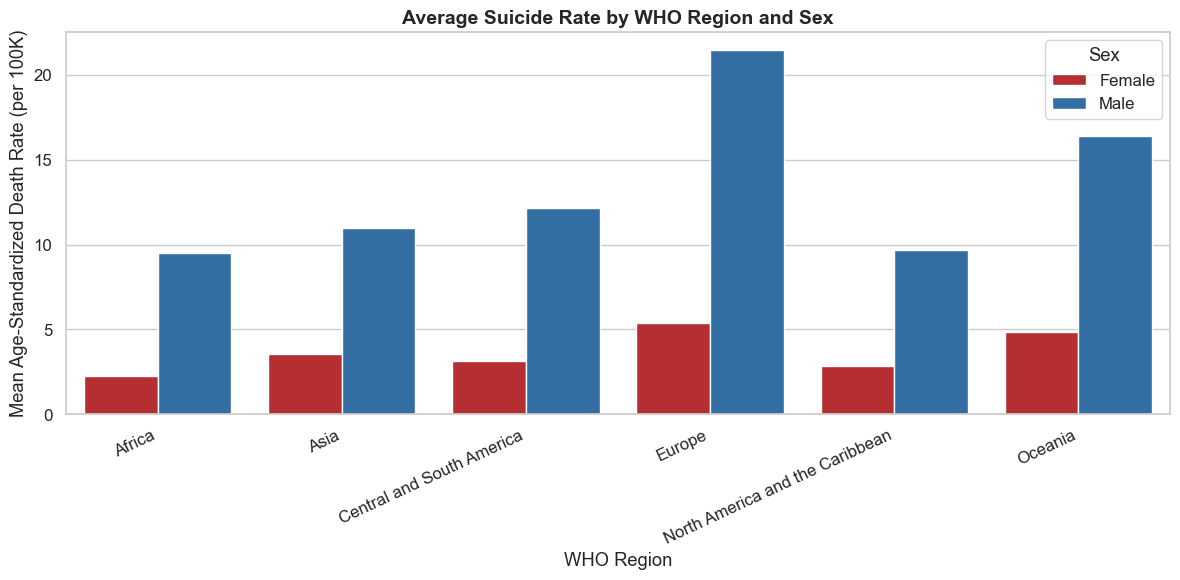

In [4]:
# Compare average suicide rates across WHO regions, split by sex
region_data = df_agestd.groupby(['RegionName', 'Sex'])['StdDeathRate'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=region_data, x='RegionName', y='StdDeathRate', hue='Sex',
            palette={'Male': '#2171b5', 'Female': '#cb181d'}, ax=ax)

ax.set_xlabel('WHO Region')
ax.set_ylabel('Mean Age-Standardized Death Rate (per 100K)')
ax.set_title('Average Suicide Rate by WHO Region and Sex', fontsize=14, fontweight='bold')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('fig_regional_comparison.png', bbox_inches='tight')
plt.show()

---
## 4. Income Group Box Plots: The Protective Paradox

Box plots comparing the distribution of StdDeathRate between High-Income and Low/Middle-Income nations. According to Lyu et al. (2025), economic growth is protective in low-income nations but may be associated with *higher* rates in high-income nations due to social pressure and status anxiety.

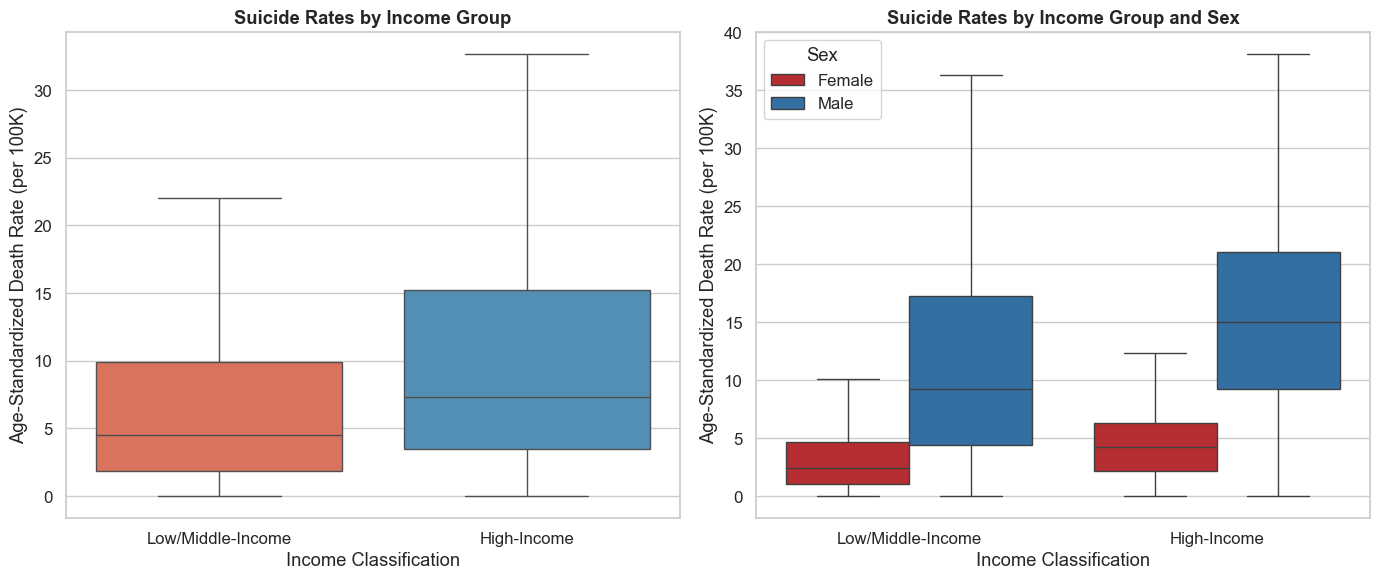


Median StdDeathRate by Income Group and Sex:
Sex                Female   Male
IncomeGroup                     
High-Income          4.24  15.02
Low/Middle-Income    2.46   9.27


In [5]:
# Box plots comparing suicide rates between High-Income and Low/Middle-Income nations
# This tests the "Protective Paradox" idea
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Overall comparison
sns.boxplot(data=df_agestd, x='IncomeGroup', y='StdDeathRate',
            palette={'High-Income': '#4292c6', 'Low/Middle-Income': '#ef6548'},
            ax=axes[0], showfliers=False)
axes[0].set_title('Suicide Rates by Income Group', fontweight='bold')
axes[0].set_xlabel('Income Classification')
axes[0].set_ylabel('Age-Standardized Death Rate (per 100K)')

# By sex within income groups
sns.boxplot(data=df_agestd, x='IncomeGroup', y='StdDeathRate', hue='Sex',
            palette={'Male': '#2171b5', 'Female': '#cb181d'},
            ax=axes[1], showfliers=False)
axes[1].set_title('Suicide Rates by Income Group and Sex', fontweight='bold')
axes[1].set_xlabel('Income Classification')
axes[1].set_ylabel('Age-Standardized Death Rate (per 100K)')

plt.tight_layout()
plt.savefig('fig_income_group_boxplots.png', bbox_inches='tight')
plt.show()

# Print medians for the discussion section
print('\nMedian StdDeathRate by Income Group and Sex:')
print(df_agestd.groupby(['IncomeGroup', 'Sex'])['StdDeathRate'].median().round(2).unstack())

---
## 5. Scatter Plots: Economic Variables vs. Suicide Rates

Scatter plots showing the relationship between individual economic predictors and the StdDeathRate, colored by income group. These plots visually test whether the direction and strength of economic relationships differ between income groups.

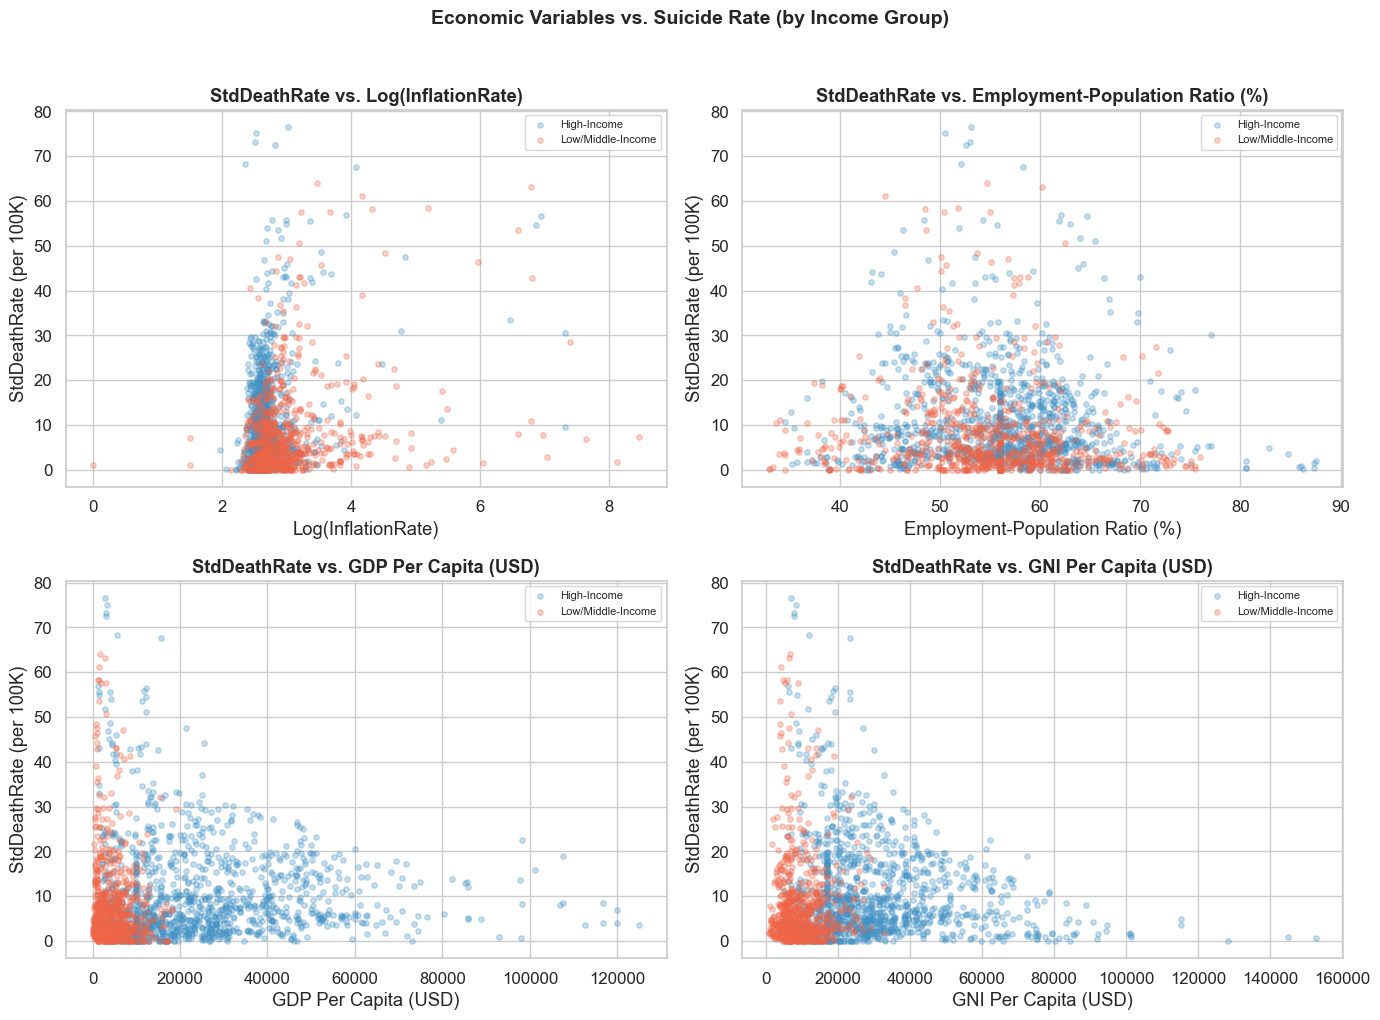

In [6]:
# Scatter plots showing how each economic variable relates to suicide rates
# Colored by income group to see if the relationship differs
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

scatter_vars = [
    ('InflationRate_Log', 'Log(InflationRate)'),
    ('EmploymentPopulationRatio', 'Employment-Population Ratio (%)'),
    ('GDPPerCapita', 'GDP Per Capita (USD)'),
    ('GNIPerCapita', 'GNI Per Capita (USD)')
]

colors = {'High-Income': '#4292c6', 'Low/Middle-Income': '#ef6548'}

for ax, (col, label) in zip(axes.flat, scatter_vars):
    if col not in df_agestd.columns:
        continue
    # Sample for plotting performance
    sample = df_agestd.dropna(subset=[col, 'StdDeathRate']).sample(
        n=min(2000, len(df_agestd)), random_state=42)
    
    for group, color in colors.items():
        mask = sample['IncomeGroup'] == group
        ax.scatter(sample.loc[mask, col], sample.loc[mask, 'StdDeathRate'],
                   alpha=0.3, s=15, color=color, label=group)
    
    ax.set_xlabel(label)
    ax.set_ylabel('StdDeathRate (per 100K)')
    ax.set_title(f'StdDeathRate vs. {label}', fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Economic Variables vs. Suicide Rate (by Income Group)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_scatter_economic.png', bbox_inches='tight')
plt.show()

---
## 6. Top/Bottom Countries by Suicide Rate

Identifies the countries with the highest and lowest average age-standardized suicide rates across the full 1990-2022 period.

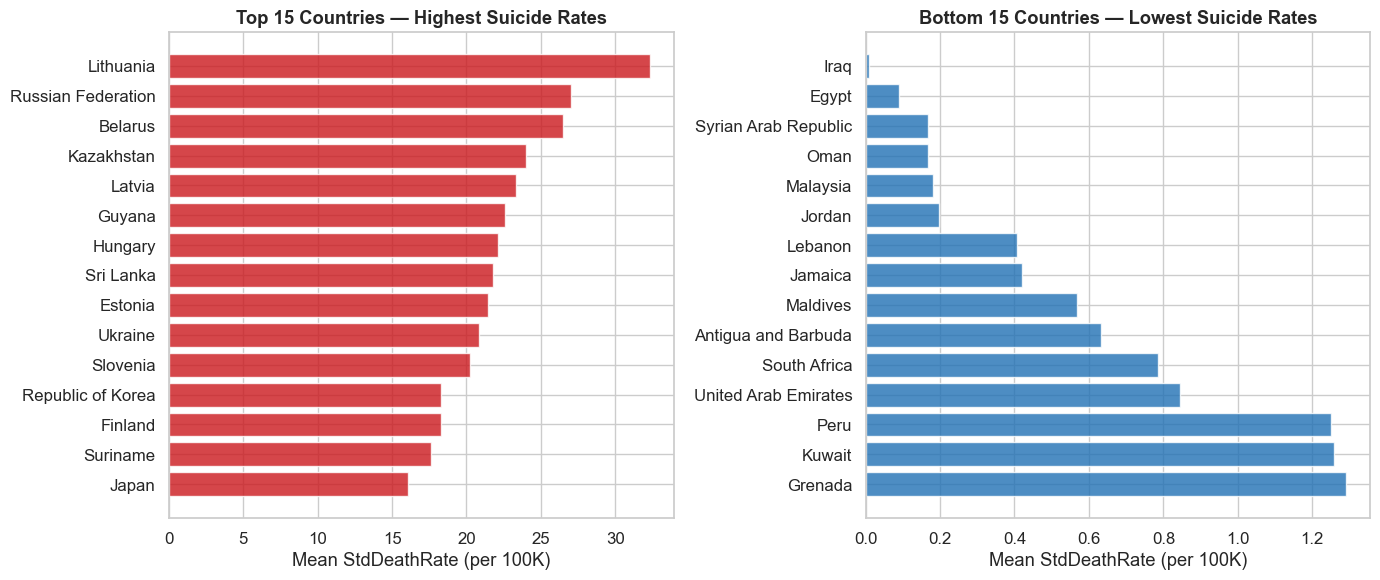

In [7]:
# Rank countries by their average suicide rate (both sexes combined)
country_avg = df_agestd.groupby('CountryName')['StdDeathRate'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 15 highest
top15 = country_avg.head(15)
axes[0].barh(range(len(top15)), top15.values, color='#cb181d', alpha=0.8)
axes[0].set_yticks(range(len(top15)))
axes[0].set_yticklabels(top15.index)
axes[0].invert_yaxis()
axes[0].set_xlabel('Mean StdDeathRate (per 100K)')
axes[0].set_title('Top 15 Countries — Highest Suicide Rates', fontweight='bold')

# Bottom 15 lowest
bottom15 = country_avg.tail(15).sort_values()
axes[1].barh(range(len(bottom15)), bottom15.values, color='#2171b5', alpha=0.8)
axes[1].set_yticks(range(len(bottom15)))
axes[1].set_yticklabels(bottom15.index)
axes[1].invert_yaxis()
axes[1].set_xlabel('Mean StdDeathRate (per 100K)')
axes[1].set_title('Bottom 15 Countries — Lowest Suicide Rates', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_country_rankings.png', bbox_inches='tight')
plt.show()

---
## Discussion of Key Patterns

### Regional and Sex Disparities
- **Europe** consistently shows the highest average suicide rates across all regions, while **Africa** and the **Eastern Mediterranean** report the lowest. However, the low rates in Africa may partly reflect under-reporting due to cultural stigma and legal issues (a known limitation noted in the lit review).
- **Males have significantly higher suicide rates than females** across all regions and time periods. This aligns with Meda et al. (2022), who found that a 1% increase in unemployment correlates with a 1% increase in *male* suicide rates specifically, and that the working-age male population (30-59 years) is the most sensitive demographic.

### Time-Series Trends and Economic Crises
- A visible **peak in the mid-to-late 1990s** followed by a gradual decline aligns with the collapse of the Soviet Union and subsequent economic turmoil in Eastern European countries.
- The **2008 Financial Crisis** period shows a disruption in the downward trend — rates either flatten or slightly increase in some regions, consistent with Reeves et al. (2014) finding of delayed, prolonged rises in suicide following unemployment spikes.
- The **COVID-19 period** (2020-2021) shows varied effects that require closer country-level analysis to interpret.

### The Protective Paradox
- **High-Income nations tend to show higher median suicide rates** than Low/Middle-Income nations, providing initial visual evidence for the Protective Paradox identified by Lyu et al. (2025). Economic growth appears protective in developing countries but may correlate with higher rates in wealthy nations due to social pressure and status anxiety.
- This finding validates the project's decision to stratify models by income level (Research Question 3).

### Economic Relationships
- The correlation heatmap and scatter plots reveal that **no single economic variable has a strong linear correlation** with suicide rates when analyzed globally. This underscores the need for:
  1. **Income-group stratification** (different dynamics in high vs. low-income countries)
  2. **Temporal lagging** (economic impacts operate on a delay)
  3. **Multivariate regression** (effects are intertwined, not independent)
- EmploymentPopulationRatio and GDPPerCapita show nuanced, non-uniform relationships that differ by income group — further supporting the methodology of building separate models per stratum.